# 🧬 CNN on Microscope Images — 224x224 (PyTorch)
**Public dataset:** BloodMNIST (MedMNIST) at **224x224** resolution — real microscope bright-field images of 8 blood-cell types.
A plain CNN (no BatchNorm, no augmentation) used directly for classification.


In [1]:
# ============================================================
# Setup & download high-resolution microscope dataset (224x224)
# ============================================================
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from medmnist import BloodMNIST

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- BloodMNIST at native high resolution (224x224) ----
train_ds = BloodMNIST(split="train", download=True, size=224)
test_ds  = BloodMNIST(split="test",  download=True, size=224)
class_names = [train_ds.info["label"][str(i)] for i in range(8)]
print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
print(f"Image shape: {np.array(train_ds[0][0]).shape} (RGB)")


Device: cpu


Train: 11959 | Test: 3421
Image shape: (224, 224, 3) (RGB)


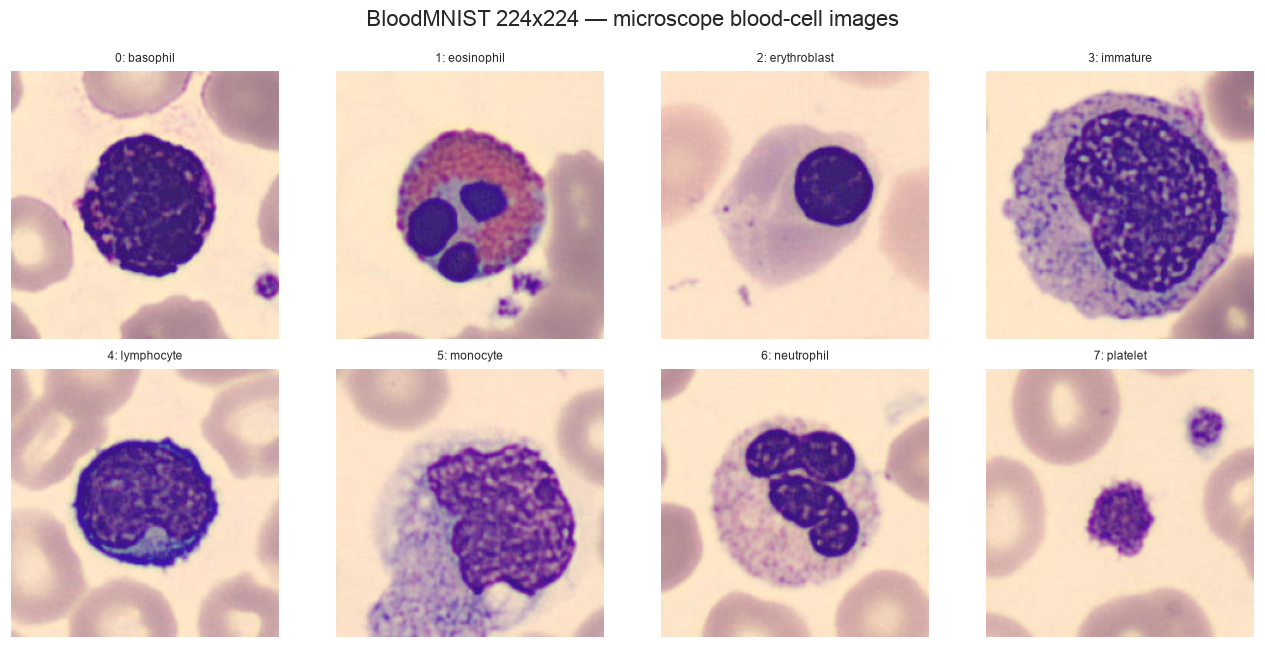

In [2]:
# ============================================================
# Visualize samples (224x224)
# ============================================================
# One pass: record the first index of each class, then decode ONLY 8 images
# (the naive nested loop re-decodes hundreds of 224x224 images, which is slow)
first_idx = {}
for i, (_, label) in enumerate(train_ds):
    c = int(label[0])
    if c not in first_idx:
        first_idx[c] = i
    if len(first_idx) == len(class_names):
        break

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, c in zip(axes.flat, sorted(first_idx)):
    img = np.array(train_ds[first_idx[c]][0])
    ax.imshow(img)
    ax.set_title(f"{c}: {class_names[c].split()[0]}", fontsize=8)
    ax.axis("off")
plt.suptitle("BloodMNIST 224x224 — microscope blood-cell images")
plt.tight_layout(); plt.show()

In [3]:
# ============================================================
# DataLoaders + plain CNN (no BatchNorm, no augmentation)
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3),
])


class MedDataset(Dataset):
    def __init__(self, ds, transform=None):
        self.ds = ds
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, i):
        img, label = self.ds[i]
        if self.transform is not None:
            img = self.transform(img)
        return img, torch.tensor(int(label[0]), dtype=torch.long)


train_loader = DataLoader(MedDataset(train_ds, transform),
                          batch_size=64, shuffle=True)
test_loader  = DataLoader(MedDataset(test_ds, transform),
                          batch_size=64, shuffle=False)


class BloodCNN(nn.Module):
    """3 conv blocks + global average pooling (no BatchNorm)."""
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.fc(x.flatten(1))


model = BloodCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters()):,}")


BloodCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Linear(in_features=128, out_features=8, bias=True)
)
Trainable params: 94,280


In [4]:
# ============================================================
# Training loop (6 epochs, ~3 min/epoch on CPU at 224px)
# ============================================================
def train_one_epoch(loader, model, criterion, optimizer, device):
    model.train()
    total = correct = 0
    loss_sum = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += yb.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(loader, model, device):
    model.eval()
    total = correct = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        correct += (model(xb).argmax(1) == yb).sum().item()
        total += yb.size(0)
    return correct / total


EPOCHS = 6
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(train_loader, model, criterion,
                                      optimizer, device)
    te_acc = evaluate(test_loader, model, device)
    print(f"Epoch {epoch:2d} | loss {tr_loss:.4f} | train acc {tr_acc:.4f} | "
          f"test acc {te_acc:.4f} | {time.time()-t0:.0f}s")


Epoch  1 | loss 1.3156 | train acc 0.5141 | test acc 0.6489 | 210s


Epoch  2 | loss 0.8115 | train acc 0.6894 | test acc 0.7407 | 184s


Epoch  3 | loss 0.6618 | train acc 0.7619 | test acc 0.7828 | 199s


Epoch  4 | loss 0.5798 | train acc 0.7921 | test acc 0.8325 | 227s


Epoch  5 | loss 0.5158 | train acc 0.8226 | test acc 0.8386 | 214s


Epoch  6 | loss 0.4839 | train acc 0.8343 | test acc 0.8308 | 206s


Test accuracy: 0.8308
                                                                     precision    recall  f1-score   support

                                                           basophil     0.6931    0.7869    0.7370       244
                                                         eosinophil     0.9982    0.9119    0.9531       624
                                                       erythroblast     0.7989    0.9068    0.8494       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)     0.7550    0.5268    0.6205       579
                                                         lymphocyte     0.8009    0.7284    0.7629       243
                                                           monocyte     0.7188    0.7289    0.7238       284
                                                         neutrophil     0.7646    0.9655    0.8534       666
                                                           platelet     1.0000    0.9936    0.9968       

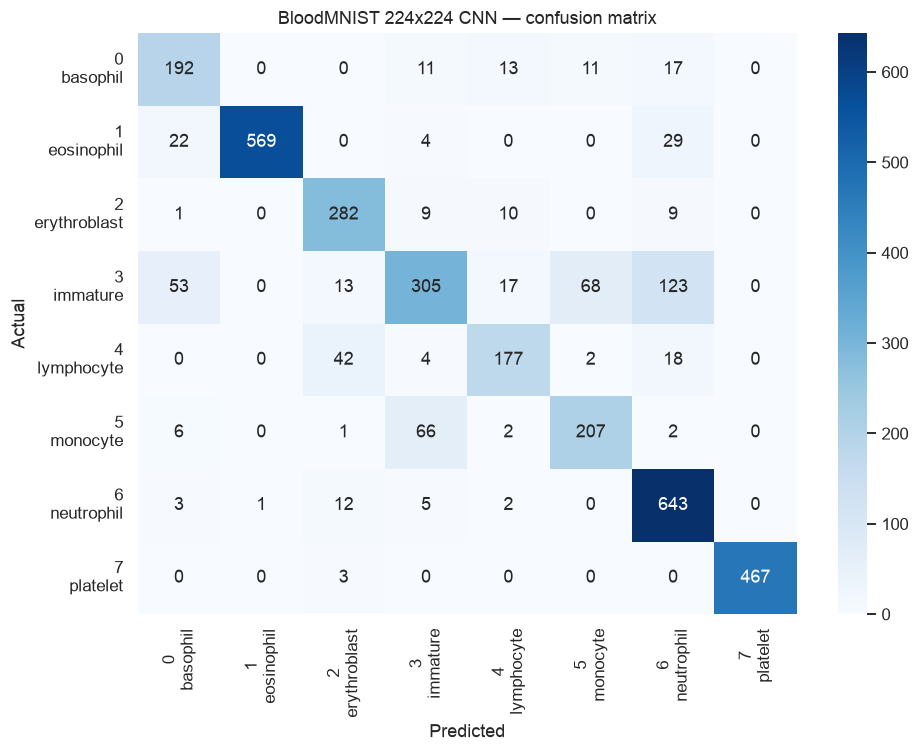

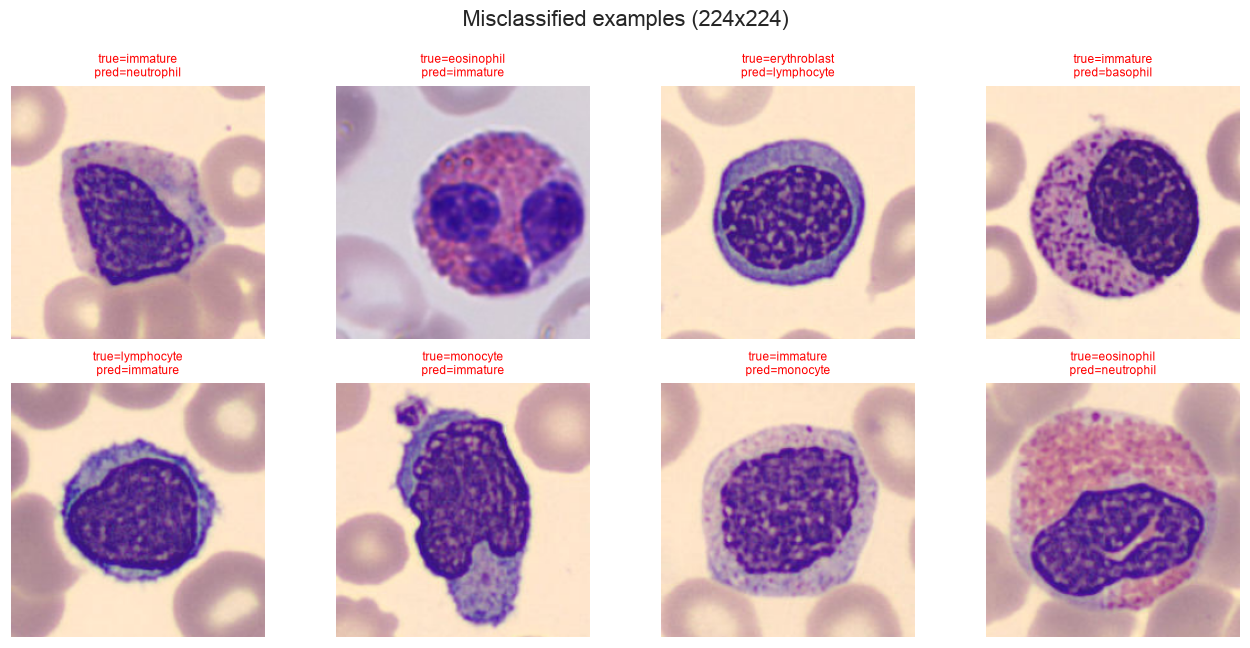

In [5]:
# ============================================================
# Evaluation — accuracy, classification report, confusion matrix
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report


@torch.no_grad()
def predict_all(loader, model, device):
    model.eval()
    ys, preds = [], []
    for xb, yb in loader:
        preds.append(model(xb.to(device)).argmax(1).cpu())
        ys.append(yb)
    return torch.cat(ys).numpy(), torch.cat(preds).numpy()


y_true, y_pred = predict_all(test_loader, model, device)
acc = (y_true == y_pred).mean()
print(f"Test accuracy: {acc:.4f}")
print(classification_report(y_true, y_pred, target_names=class_names,
                            digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"{i}\n{n.split()[0]}" for i, n in enumerate(class_names)],
            yticklabels=[f"{i}\n{n.split()[0]}" for i, n in enumerate(class_names)])
plt.title("BloodMNIST 224x224 CNN — confusion matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

# ---- misclassified examples at full resolution ----
mis_idx = np.where(y_true != y_pred)[0][:8]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = np.array(test_ds[mis_idx[i]][0])
    ax.imshow(img)
    ax.set_title(f"true={class_names[y_true[mis_idx[i]]].split()[0]}\n"
                 f"pred={class_names[y_pred[mis_idx[i]]].split()[0]}",
                 fontsize=8, color="red")
    ax.axis("off")
plt.suptitle("Misclassified examples (224x224)")
plt.tight_layout(); plt.show()
